## Predictive Modeling

Loome kaks ennustavat mudelit:
1. **Kasumi/kahjumi ennustamine:** Kas ettevõte jääb järgmisel aastal kasumisse või kahjumisse.
2. **Staatus:** Kas ettevõtte staatus muutub "Kustutatud" või "Pankrotis" staatusesse.

Selleks peame esmalt andmeid ette valmistama, leides iga ettevõtte (`registrikood`) jaoks järgmise aasta (`aruandeaasta` + 1) kasumi ja staatuse.

In [1]:
import pandas as pd

# Laeme sisse EDA märkmikus puhastatud ja salvestatud andmestiku
df_cleaned = pd.read_parquet('data/cleaned_reports_for_modeling.parquet')
print("Puhastatud andmed laetud edukalt! Ridade arv:", len(df_cleaned))

Puhastatud andmed laetud edukalt! Ridade arv: 1374020


In [10]:
# Andmete ettevalmistus mudelite jaoks
# Sorteerime andmed ettevõtte ja aasta järgi
df_model = df_cleaned.sort_values(by=['registrikood', 'aruandeaasta']).copy()

# Leiame iga ettevõtte jaoks järgmise aasta kasumi/kahjumi ja staatuse
df_model['NextYear_ProfitLoss'] = df_model.groupby('registrikood')['TotalAnnualPeriodProfitLoss'].shift(-1)
df_model['NextYear_Status'] = df_model.groupby('registrikood')['staatus'].shift(-1)

# Loome sihtmuutujad (target variables)
# 1. Mudel: Järgmise aasta kasum (1 = kasum, 0 = kahjum või null)
df_model['Target_Profit'] = (df_model['NextYear_ProfitLoss'] > 0).astype(int)

# 2. Mudel: Järgmise aasta staatus (1 = Registrisse kantud (Aktiivne), 0 = Kustutatud/Pankrotis/Likvideerimisel)
# ~ operaator muudab tõeväärtused vastupidiseks: kui on kustutatud/pankrotis, siis on 0, muidu 1.
df_model['Target_Status'] = (~df_model['NextYear_Status'].isin(['Kustutatud', 'Pankrotis', 'Likvideerimisel'])).astype(int) 

# Jätame alles ainult need read, kus meil on järgmise aasta andmed olemas (ehk shift(-1) ei ole NaN)
# Erandiks staatus, kus võime teada, et järgmisel aastal andmeid pole, mis võibki viidata kustutamisele,
# aga praegu kasutame puhast shifti.
df_model_ready = df_model.dropna(subset=['NextYear_ProfitLoss', 'NextYear_Status']).copy()

print(f"Andmeridade arv mudeli treenimiseks: {len(df_model_ready)}")
df_model_ready[['registrikood', 'aruandeaasta', 'TotalAnnualPeriodProfitLoss', 'staatus', 'NextYear_ProfitLoss', 'NextYear_Status', 'Target_Profit', 'Target_Status']].head()

Andmeridade arv mudeli treenimiseks: 1073870


,registrikood,aruandeaasta,TotalAnnualPeriodProfitLoss,staatus,NextYear_ProfitLoss,NextYear_Status,Target_Profit,Target_Status
47587,10000018,2019,1506266.0,Registrisse kantud,1321525.0,Registrisse kantud,1,1
221151,10000018,2020,1321525.0,Registrisse kantud,5785994.0,Registrisse kantud,1,1
427409,10000018,2021,5785994.0,Registrisse kantud,1338647.0,Registrisse kantud,1,1
649955,10000018,2022,1338647.0,Registrisse kantud,3540437.0,Registrisse kantud,1,1
901565,10000018,2023,3540437.0,Registrisse kantud,3532612.0,Registrisse kantud,1,1


### Mudel 1: Järgmise aasta kasumi ennustamine (Aastapõhine / Walk-Forward)

Selleks, et vältida andmeleket (*data leakage*) ja simuleerida päriselu olukorda, treenime mudeli ühe aasta andmetel ja testime järgmise aasta andmetel. 
Näiteks: Treenime mudeli 2019. aasta andmetel (kus eesmärk on ennustada 2020. a kasumit) ning testime mudelit 2020. aasta andmetel (kus mudel teeb ennustuse 2021. a kasumi kohta, tuginedes õpitule). Nii saame iga aasta kohta konkreetsed mõõdikud, mida hiljem Streamliti äpis visualiseerida.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Valime numbrilised tunnused mudeli jaoks
possible_features = ['Assets', 'Töötajate_arv', 'CurrentAssets', 'CurrentLiabilities', 
            'Equity', 'IssuedCapital', 'LaborExpense', 'RetainedEarningsLoss', 
            'Revenue', 'TotalAnnualPeriodProfitLoss']

# Tagame, et kasutame ainult neid veerge, mis eksisteerivad tabelis
features = [f for f in possible_features if f in df_model_ready.columns]

min_year = df_model_ready['aruandeaasta'].min()
max_year = df_model_ready['aruandeaasta'].max()

results_list_profit = []

print(f"Andmete periood (alusandmed): {min_year} - {max_year}")
print("--- MUDEL 1: KASUMI ENNUSTAMINE (Aastapõhine Walk-Forward) ---\n")

for year in range(min_year, max_year):
    train_year = year
    test_year = year + 1
    
    # Treeningandmed: Mudel õpib train_year tunnustest (ennustades train_year+1 kasumit)
    df_train = df_model_ready[df_model_ready['aruandeaasta'] == train_year]
    
    # Testandmed: Mudelit testitakse test_year tunnustel (kus see ennustab test_year+1 kasumit)
    df_test = df_model_ready[df_model_ready['aruandeaasta'] == test_year]
    
    if len(df_train) == 0 or len(df_test) == 0:
        continue
        
    X_train = df_train[features].fillna(0)
    y_train = df_train['Target_Profit']
    
    X_test = df_test[features].fillna(0)
    y_test = df_test['Target_Profit']
    
    # Kasutame juhuslikku metsa mudelit (Random Forest)
    rf_model1 = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1, max_depth=10)
    rf_model1.fit(X_train, y_train)
    
    y_pred = rf_model1.predict(X_test)
    
    # Arvutame mõõdikud
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    actual_pct = (y_test.sum() / len(y_test)) * 100
    pred_pct = (y_pred.sum() / len(y_pred)) * 100
    error_pp = abs(actual_pct - pred_pct)
    
    print(f"Treenitud: {train_year} | Testitud: {test_year} (Sihtmärk: {test_year+1}. a kasum)")
    print(f"  Tegelik kasumis %: {actual_pct:.1f}% | Ennustatud kasumis %: {pred_pct:.1f}%")
    print(f"  Viga (protsendipunktides): {error_pp:.1f} pp")
    print(f"  Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}\n")
    
    results_list_profit.append({
        'Train_Year': train_year,
        'Test_Year': test_year,
        'Target_Year': test_year + 1,
        'Actual_Pct': actual_pct,
        'Predicted_Pct': pred_pct,
        'Error_PP': error_pp,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1_Score': f1
    })

# Salvestame tulemused DataFrame'i ja CSV faili Streamliti jaoks
df_results_profit = pd.DataFrame(results_list_profit)
df_results_profit.to_csv('data/model1_yearly_results.csv', index=False)
print("Tulemused salvestatud: data/model1_yearly_results.csv")

Andmete periood (alusandmed): 2019 - 2024
--- MUDEL 1: KASUMI ENNUSTAMINE (Aastapõhine Walk-Forward) ---

Treenitud: 2019 | Testitud: 2020 (Sihtmärk: 2021. a kasum)
  Tegelik kasumis %: 49.4% | Ennustatud kasumis %: 55.8%
  Viga (protsendipunktides): 6.5 pp
  Accuracy: 0.7681 | Precision: 0.7344 | Recall: 0.8307 | F1: 0.7796

Treenitud: 2020 | Testitud: 2021 (Sihtmärk: 2022. a kasum)
  Tegelik kasumis %: 48.3% | Ennustatud kasumis %: 62.3%
  Viga (protsendipunktides): 14.1 pp
  Accuracy: 0.7582 | Precision: 0.6931 | Recall: 0.8954 | F1: 0.7814

Treenitud: 2021 | Testitud: 2022 (Sihtmärk: 2023. a kasum)
  Tegelik kasumis %: 48.4% | Ennustatud kasumis %: 60.6%
  Viga (protsendipunktides): 12.1 pp
  Accuracy: 0.7466 | Precision: 0.6908 | Recall: 0.8634 | F1: 0.7675

Treenitud: 2022 | Testitud: 2023 (Sihtmärk: 2024. a kasum)
  Tegelik kasumis %: 48.1% | Ennustatud kasumis %: 59.9%
  Viga (protsendipunktides): 11.9 pp
  Accuracy: 0.7441 | Precision: 0.6874 | Recall: 0.8573 | F1: 0.7630

Tre

### Mudel 2: Staatuse muutumise ennustamine (Aastapõhine / Walk-Forward)

Sama loogika nagu Mudel 1 puhul: treenime mudeli ühe aasta andmetel ja testime järgmise aasta andmetel.
`Target_Status` on 1, kui ettevõte on järgmisel aastal aktiivne, ja 0, kui see on kustutatud/pankrotis.

In [12]:
# Mudel 2: Järgmise aasta staatus (1 = Registrisse kantud, 0 = Kustutatud/Pankrotis/Likvideerimisel)

results_list_status = []
print("--- MUDEL 2: STAATUSE ENNUSTAMINE (Aastapõhine Walk-Forward) ---\n")

for year in range(min_year, max_year):
    train_year = year
    test_year = year + 1
    
    # Treeningandmed
    df_train = df_model_ready[df_model_ready['aruandeaasta'] == train_year]
    
    # Testandmed
    df_test = df_model_ready[df_model_ready['aruandeaasta'] == test_year]
    
    if len(df_train) == 0 or len(df_test) == 0:
        continue
        
    X_train = df_train[features].fillna(0)
    y_train = df_train['Target_Status']
    
    X_test = df_test[features].fillna(0)
    y_test = df_test['Target_Status']
    
    # Kasutame tasakaalustatud kaaludega (class_weight='balanced') mudelit
    rf_model2 = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1, max_depth=10, class_weight='balanced')
    rf_model2.fit(X_train, y_train)
    
    y_pred = rf_model2.predict(X_test)
    
    # Arvutame mõõdikud
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    actual_pct = (y_test.sum() / len(y_test)) * 100
    pred_pct = (y_pred.sum() / len(y_pred)) * 100
    error_pp = abs(actual_pct - pred_pct)
    
    print(f"Treenitud: {train_year} | Testitud: {test_year} (Sihtmärk: {test_year+1}. a staatus)")
    print(f"  Tegelik aktiivne %: {actual_pct:.1f}% | Ennustatud aktiivne %: {pred_pct:.1f}%")
    print(f"  Viga (protsendipunktides): {error_pp:.1f} pp")
    print(f"  Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}\n")
    
    results_list_status.append({
        'Train_Year': train_year,
        'Test_Year': test_year,
        'Target_Year': test_year + 1,
        'Actual_Pct': actual_pct,
        'Predicted_Pct': pred_pct,
        'Error_PP': error_pp,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1_Score': f1
    })

# Salvestame tulemused DataFrame'i ja CSV faili Streamliti jaoks
df_results_status = pd.DataFrame(results_list_status)
df_results_status.to_csv('data/model2_yearly_results.csv', index=False)
print("Tulemused salvestatud: data/model2_yearly_results.csv")

--- MUDEL 2: STAATUSE ENNUSTAMINE (Aastapõhine Walk-Forward) ---

Treenitud: 2019 | Testitud: 2020 (Sihtmärk: 2021. a staatus)
  Tegelik aktiivne %: 90.2% | Ennustatud aktiivne %: 68.5%
  Viga (protsendipunktides): 21.7 pp
  Accuracy: 0.7106 | Precision: 0.9471 | Recall: 0.7194 | F1: 0.8177

Treenitud: 2020 | Testitud: 2021 (Sihtmärk: 2022. a staatus)
  Tegelik aktiivne %: 92.8% | Ennustatud aktiivne %: 71.6%
  Viga (protsendipunktides): 21.3 pp
  Accuracy: 0.7294 | Precision: 0.9594 | Recall: 0.7398 | F1: 0.8354

Treenitud: 2021 | Testitud: 2022 (Sihtmärk: 2023. a staatus)
  Tegelik aktiivne %: 96.0% | Ennustatud aktiivne %: 72.2%
  Viga (protsendipunktides): 23.9 pp
  Accuracy: 0.7298 | Precision: 0.9781 | Recall: 0.7350 | F1: 0.8393

Treenitud: 2022 | Testitud: 2023 (Sihtmärk: 2024. a staatus)
  Tegelik aktiivne %: 97.7% | Ennustatud aktiivne %: 76.8%
  Viga (protsendipunktides): 20.9 pp
  Accuracy: 0.7717 | Precision: 0.9874 | Recall: 0.7761 | F1: 0.8691

Treenitud: 2023 | Testitud

### Tunnuste olulisus (Feature Importance)

Vaatame, millised finantsnäitajad mõjutavad kõige enam ettevõtte kasumisse jäämist või pankrotti/kustutamist.

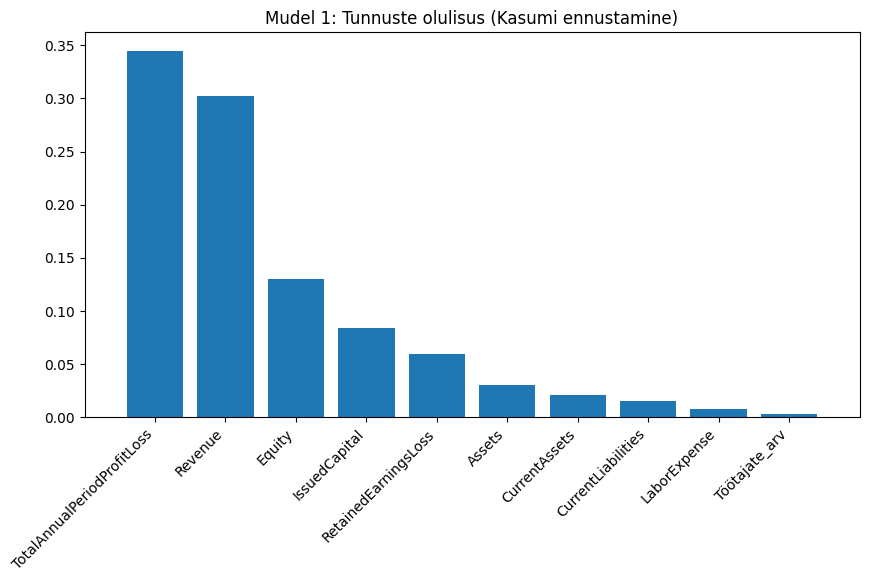

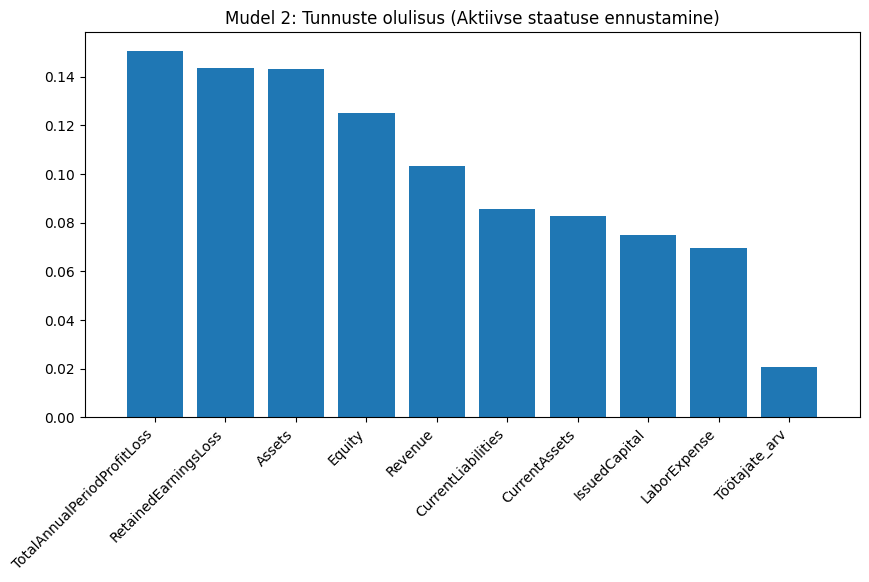

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Mudel 1 (Kasumi ennustamine) tunnuste olulisus
importances1 = rf_model1.feature_importances_
indices1 = np.argsort(importances1)[::-1]

plt.figure(figsize=(10, 5))
plt.title("Mudel 1: Tunnuste olulisus (Kasumi ennustamine)")
plt.bar(range(len(features)), importances1[indices1], align="center")
plt.xticks(range(len(features)), [features[i] for i in indices1], rotation=45, ha='right')
plt.xlim([-1, len(features)])
plt.show()

# Mudel 2 (Aktiivse staatuse ennustamine) tunnuste olulisus
importances2 = rf_model2.feature_importances_
indices2 = np.argsort(importances2)[::-1]

plt.figure(figsize=(10, 5))
plt.title("Mudel 2: Tunnuste olulisus (Aktiivse staatuse ennustamine)")
plt.bar(range(len(features)), importances2[indices2], align="center")
plt.xticks(range(len(features)), [features[i] for i in indices2], rotation=45, ha='right')
plt.xlim([-1, len(features)])
plt.show()